# Heston Model — American Option Pricing via ADI method

Alternating Direction Implicit (ADI) finite-difference schemes for the Heston PDE, which carries a **mixed** $S\!-\!v$ derivative term. The schemes differ in how that mixed term is corrected:

| Scheme | Mixed term | Order* | Stability | Cost / step |
|---|---|:---:|---|---|
| **Douglas (Do)** | explicit, no corrector | 1st | conditional (fragile) | cheapest (2 solves) |
| **Craig–Sneyd (CS)** | + 1 corrector | 2nd | limited | + 1 stage |
| **Modified Craig–Sneyd (MCS)** | + 1 corrector | 2nd | good / robust | + 1 stage |
| **Hundsdorfer–Verwer (HV)** | + 2 correctors | 2nd | best (strong $\rho$ / vol-of-vol) | + 2 stages |

<sub>\*Order = time accuracy in the presence of the mixed term.</sub>

This notebook implements the two most contrasting schemes, to compare them:
- **HV** - solved with `scipy.linalg.solve_banded`
- **Douglas** - solved with sparse `scipy.sparse.linalg.spsolve`


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from scipy import sparse
from scipy.fft import fft
from scipy.interpolate import interp1d
from scipy.stats import norm
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from scipy.integrate import quad
from scipy.interpolate import RectBivariateSpline
import scipy.linalg as linalg
import scipy.optimize as optimize

import warnings
warnings.filterwarnings('ignore')

# --- Option Pricing Calculations ---

# --- 1. Define Heston Model, Option, and Grid Parameters and Option Details ---

# Model parameters
v0 = 0.04       # Initial variance (20% volatility)
theta = 0.04    # Long-run variance
kappa = 2.0     # Speed of mean reversion
sigma = 0.3     # Volatility of variance ('vol of vol')
rho = -0.7      # Correlation between asset and variance (typically negative)
#Market Option parameters
S0 = 100.0      # Initial stock price
K = 100.0       # Strike price
T = 1.0         # Time to maturity (1 year)
r = 0.03        # Risk-free rate (3%)
q = 0.02        # Dividend yield (2%)

# Grid parameters
N_S = 200       # Number of stock price steps
N_v = 50        # Number of variance steps
N_t = 100       # Number of time steps
S_max = 2 * K   # Max stock price
v_max = 0.5     # Max variance

In [3]:
# --- 2. Define Pricing Function ---

def price_american_put_heston_hv_banded(params, option_params, grid_params):
    """
    Prices an American put using the Hundsdorfer-Verwer (HV) ADI scheme,
    solved with linalg.solve_banded.

    The HV scheme uses two predictor-corrector sweeps per time step (this is what
    makes it second order in the presence of the mixed S-v derivative; a single
    sweep would only be the first-order Douglas scheme). The mixed term L_sv is
    treated explicitly, while the directional operators L_S and L_v are corrected
    implicitly via tridiagonal solves.
    """
    # Unpack parameters
    v0, theta, kappa, sigma, rho = params
    K, T, r, q, S0 = option_params
    N_S, N_v, N_t, S_max, v_max = grid_params

    # Create Discretization Grids
    S_grid = np.linspace(0, S_max, N_S + 1)
    v_grid = np.linspace(0, v_max, N_v + 1)
    t_grid = np.linspace(0, T, N_t + 1)

    dS = S_grid[1] - S_grid[0]
    dv = v_grid[1] - v_grid[0]
    dt = t_grid[1] - t_grid[0]

    # Initialize grid for option values
    V = np.zeros((N_S + 1, N_v + 1))
    S_mat, v_mat = np.meshgrid(S_grid, v_grid, indexing='ij')

    # Set terminal condition (payoff at maturity)
    V = np.maximum(K - S_mat, 0)

    theta_hv = 0.5 + np.sqrt(3)/6     # HV stability parameter

    # Effect of operators L_S, L_v, L_sv on a grid W (factored out so the HV
    # scheme can evaluate it on both V_n and the intermediate solution Y2)
    def operators(W):
        LS, LV, LSV = np.zeros_like(W), np.zeros_like(W), np.zeros_like(W)
        for i in range(1, N_S):
            for j in range(1, N_v):
                d2V_dS2 = (W[i+1, j] - 2*W[i, j] + W[i-1, j]) / dS**2
                dV_dS = (W[i+1, j] - W[i-1, j]) / (2*dS)
                LS[i, j] = 0.5*v_grid[j]*S_grid[i]**2*d2V_dS2 + (r - q)*S_grid[i]*dV_dS - r*W[i, j]

                d2V_dv2 = (W[i, j+1] - 2*W[i, j] + W[i, j-1]) / dv**2
                dV_dv = (W[i, j+1] - W[i, j-1]) / (2*dv)
                LV[i, j] = 0.5*sigma**2*v_grid[j]*d2V_dv2 + kappa*(theta-v_grid[j])*dV_dv

                d2V_dSdv = (W[i+1,j+1] - W[i-1,j+1] - W[i+1,j-1] + W[i-1,j-1]) / (4*dS*dv)
                LSV[i, j] = rho*sigma*v_grid[j]*S_grid[i]*d2V_dSdv

        # v = 0 degenerate row: no diffusion, one-sided forward difference in v
        LS[1:-1, 0] = (r - q)*S_grid[1:-1]*(W[2:, 0] - W[:-2, 0])/(2*dS) - r*W[1:-1, 0]
        LV[1:-1, 0] = kappa*theta*(W[1:-1, 1] - W[1:-1, 0])/dv
        return LS, LV, LSV

    # Boundary conditions
    def apply_bc(W, tau):
        W[0, :] = K * np.exp(-r * tau)   # S = 0
        W[-1, :] = 0                     # S = S_max
        W[:, -1] = W[:, -2]              # Neumann at v = v_max
        return W

    # Implicit S-correction: (I - theta_hv*dt*L_S) X = rhs_src - theta_hv*dt*ref_LS
    def solve_S(rhs_src, ref_LS):
        X = rhs_src.copy()
        for j in range(0, N_v):
            vj = v_grid[j]
            alpha_S = 0.5*vj*S_grid[1:-1]**2/dS**2 - (r - q)*S_grid[1:-1]/(2*dS)
            beta_S = -vj*S_grid[1:-1]**2/dS**2 - r
            gamma_S = 0.5*vj*S_grid[1:-1]**2/dS**2 + (r - q)*S_grid[1:-1]/(2*dS)

            ab_S = np.zeros((3, N_S - 1))
            ab_S[0, 1:] = -theta_hv * dt * gamma_S[:-1]
            ab_S[1, :] = 1 - theta_hv * dt * beta_S
            ab_S[2, :-1] = -theta_hv * dt * alpha_S[1:]

            RHS_S = rhs_src[1:-1, j] - theta_hv * dt * ref_LS[1:-1, j]
            X[1:-1, j] = linalg.solve_banded((1, 1), ab_S, RHS_S)
        return X

    # Implicit v-correction: (I - theta_hv*dt*L_v) X = rhs_src - theta_hv*dt*ref_LV
    def solve_V(rhs_src, ref_LV):
        X = rhs_src.copy()
        vj = v_grid[0:N_v]
        alpha_v = 0.5*sigma**2*vj/dv**2 - kappa*(theta-vj)/(2*dv)
        beta_v = -sigma**2*vj/dv**2
        gamma_v = 0.5*sigma**2*vj/dv**2 + kappa*(theta-vj)/(2*dv)
        alpha_v[0] = 0.0                     # v=0 degenerate row: no diffusion,
        beta_v[0] = -kappa*theta/dv          # forward difference for the
        gamma_v[0] = kappa*theta/dv          # kappa*theta * V_v drift

        ab_v = np.zeros((3, N_v))
        ab_v[0, 1:] = -theta_hv * dt * gamma_v[:-1]
        ab_v[1, :] = 1 - theta_hv * dt * beta_v
        ab_v[2, :-1] = -theta_hv * dt * alpha_v[1:]

        for i in range(1, N_S):
            RHS_v = rhs_src[i, 0:N_v] - theta_hv * dt * ref_LV[i, 0:N_v]
            X[i, 0:N_v] = linalg.solve_banded((1, 1), ab_v, RHS_v)
        return X

    # Backward Time Iteration Loop (Hundsdorfer-Verwer Scheme)
    for n in range(N_t, 0, -1):
        tau_now = T - t_grid[n]
        tau_new = T - t_grid[n-1]

        V = apply_bc(V, tau_now)
        V_n = V.copy()                         # Solution at current time n

        # --- First sweep (predictor + directional corrections) ---
        LS_Vn, LV_Vn, LSV_Vn = operators(V_n)
        Y0 = V_n + dt * (LS_Vn + LV_Vn + LSV_Vn)    # Stage 1: explicit predictor
        Y1 = solve_S(Y0, LS_Vn)                     # Stage 2: implicit S-correction
        Y2 = solve_V(Y1, LV_Vn)                     # Stage 3: implicit v-correction
        Y2 = apply_bc(Y2, tau_new)

        # --- Second sweep (HV correction, restores 2nd order with mixed term) ---
        LS_Y2, LV_Y2, LSV_Y2 = operators(Y2)
        Yt0 = Y0 + 0.5 * dt * ((LS_Y2 + LV_Y2 + LSV_Y2) - (LS_Vn + LV_Vn + LSV_Vn))
        Yt1 = solve_S(Yt0, LS_Y2)
        V_next = solve_V(Yt1, LV_Y2)
        V_next = apply_bc(V_next, tau_new)

        # Enforce American Early Exercise
        payoff = np.maximum(K - S_mat, 0)
        V = np.maximum(V_next, payoff)

    # Interpolate to find price at (S0, v0)
    spline = RectBivariateSpline(S_grid, v_grid, V)
    price = spline(S0, v0)[0][0]

    return price, V

--- Heston American Put Price (HV Scheme with solve_banded) ---
Grid Size (S x v x t): 200 x 50 x 100
Option Price at S0=100.0, v0=0.04: 7.1319



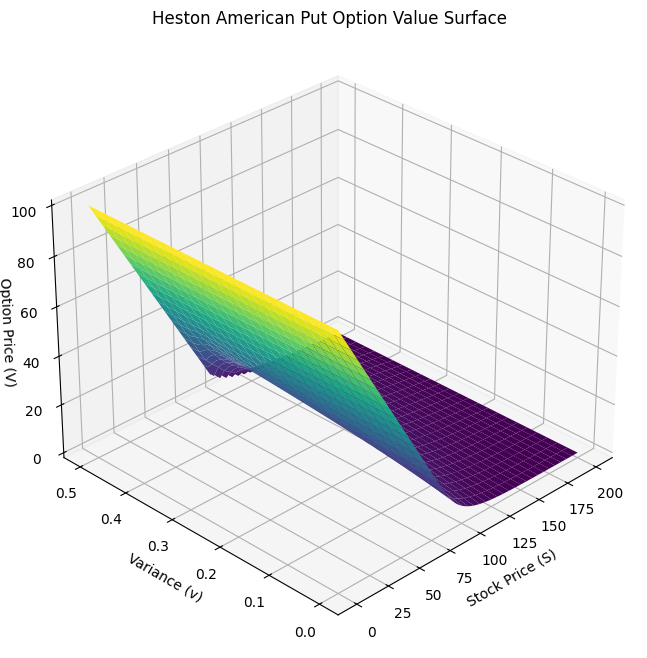

In [4]:
# --- 3. Run Optimization Function and visualize results ---

if __name__ == '__main__':
    # Pack parameters into tuples
    model_params = (v0, theta, kappa, sigma, rho)
    option_params = (K, T, r, q, S0)
    grid_params = (N_S, N_v, N_t, S_max, v_max)

    S_grid = np.linspace(0, S_max, N_S + 1)
    v_grid = np.linspace(0, v_max, N_v + 1)

    # Calculate the price
    price, V_surface = price_american_put_heston_hv_banded(model_params, option_params, grid_params)
    
    print("--- Heston American Put Price (HV Scheme with solve_banded) ---")
    print(f"Grid Size (S x v x t): {N_S} x {N_v} x {N_t}")
    print(f"Option Price at S0={S0}, v0={v0}: {price:.4f}\n")
    
    # Plotting
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    S_mat, v_mat = np.meshgrid(S_grid, v_grid, indexing='ij')

    ax.plot_surface(S_mat, v_mat, V_surface, cmap='viridis')
    ax.set_title("Heston American Put Option Value Surface")
    ax.set_xlabel("Stock Price (S)")
    ax.set_ylabel("Variance (v)")
    ax.set_zlabel("Option Price (V)", labelpad=0)
    ax.view_init(30, -135) # Adjust viewing angle
    plt.show()
    

In [5]:
# --- 4. Option Pricing via ADI (Douglas scheme) using spsolve ---

def price_american_put_heston_spsolve(params, option_params, grid_params):
    """
    Prices an American put using the Douglas ADI scheme, solving the directional
    systems with scipy.sparse.linalg.spsolve.

    Single predictor-corrector sweep (theta = 1/2): the mixed term L_sv is treated
    explicitly in the predictor, the directional operators L_S and L_v are corrected
    implicitly. Douglas is therefore first order in time when the mixed term is
    present (the HV version in above adds a second sweep to recover second order).
    """
    v0, theta, kappa, sigma, rho = params
    K, T, r, q, S0 = option_params
    N_S, N_v, N_t, S_max, v_max = grid_params

    # Grid Parameters
    S_grid = np.linspace(0, S_max, N_S + 1)
    v_grid = np.linspace(0, v_max, N_v + 1)
    t_grid = np.linspace(0, T, N_t + 1)
    dS = S_grid[1] - S_grid[0]
    dv = v_grid[1] - v_grid[0]
    dt = t_grid[1] - t_grid[0]

    V = np.zeros((N_S + 1, N_v + 1))
    S_mat, v_mat = np.meshgrid(S_grid, v_grid, indexing='ij')
    V = np.maximum(K - S_mat, 0)

    for n in range(N_t, 0, -1):
        tau = T - t_grid[n-1]

        # Boundary conditions (S=0 Dirichlet, S=S_max=0, Neumann at v=v_max)
        V[0, :] = K * np.exp(-r * tau)
        V[-1, :] = 0
        V[:, -1] = V[:, -2]

        # Intermediate Step (Y): implicit in S, explicit in v + mixed
        Y = V.copy()
        for j in range(0, N_v):                 # j=0 (v=0) is solved via the degenerate PDE
            vj = v_grid[j]

            alpha_S = 0.25 * dt * (vj * S_grid[1:-1]**2 / dS**2 - (r - q) * S_grid[1:-1] / dS)
            beta_S = -0.5 * dt * (vj * S_grid[1:-1]**2 / dS**2 + r)
            gamma_S = 0.25 * dt * (vj * S_grid[1:-1]**2 / dS**2 + (r - q) * S_grid[1:-1] / dS)

            # A_S = I - 0.5*dt*L_S  as a sparse tridiagonal matrix
            diagonals_S = [-alpha_S[1:], 1 - beta_S, -gamma_S[:-1]]
            A_S_sparse = diags(diagonals_S, [-1, 0, 1], shape=(N_S - 1, N_S - 1), format='csc')

            # Explicit S part:  B_S_V = (I + 0.5*dt*L_S) V
            B_S_V = (V[1:-1, j] +
                     alpha_S * V[:-2, j] +
                     beta_S * V[1:-1, j] +
                     gamma_S * V[2:, j])

            # Explicit v + mixed part (full dt). v=0 uses the degenerate forward difference.
            if j == 0:
                L_v_V = kappa * theta * (V[1:-1, 1] - V[1:-1, 0]) / dv
            else:
                dv_V = (V[1:-1, j+1] - V[1:-1, j-1]) / (2 * dv)
                d2v_V = (V[1:-1, j+1] - 2 * V[1:-1, j] + V[1:-1, j-1]) / dv**2
                dSv_V = (V[2:, j+1] - V[:-2, j+1] - V[2:, j-1] + V[:-2, j-1]) / (4 * dS * dv)
                L_v_V = (0.5 * sigma**2 * vj * d2v_V + kappa * (theta - vj) * dv_V +
                         rho * sigma * vj * S_grid[1:-1] * dSv_V)

            rhs = B_S_V + dt * L_v_V
            rhs[0] += alpha_S[0] * K * np.exp(-r * tau)   # S=0 boundary contribution
            rhs[-1] += gamma_S[-1] * 0                    # S=S_max boundary (=0)

            Y[1:-1, j] = spsolve(A_S_sparse, rhs)

        Y[0, :] = K * np.exp(-r * tau)
        Y[-1, :] = 0
        Y[:, -1] = Y[:, -2]

        # Final Step (V): implicit in v. Douglas corrector:  (I - 0.5*dt*L_v) V = Y - 0.5*dt*L_v V
        vj = v_grid[0:N_v]
        alpha_v = 0.25 * dt * (sigma**2 * vj / dv**2 - kappa * (theta - vj) / dv)
        beta_v = -0.5 * dt * (sigma**2 * vj / dv**2)      
        gamma_v = 0.25 * dt * (sigma**2 * vj / dv**2 + kappa * (theta - vj) / dv)
        alpha_v[0] = 0.0                                  # v=0 degenerate row: no diffusion,
        beta_v[0] = -0.5 * dt * kappa * theta / dv        # forward difference for the
        gamma_v[0] = 0.5 * dt * kappa * theta / dv        # kappa*theta * V_v drift

        diagonals_v = [-alpha_v[1:], 1 - beta_v, -gamma_v[:-1]]
        A_v_sparse = diags(diagonals_v, [-1, 0, 1], shape=(N_v, N_v), format='csc')

        for i in range(1, N_S):
            E_v = np.empty(N_v)
            E_v[1:] = (alpha_v[1:] * V[i, 0:N_v-1] +
                       beta_v[1:] * V[i, 1:N_v] +
                       gamma_v[1:] * V[i, 2:N_v+1])
            E_v[0] = beta_v[0] * V[i, 0] + gamma_v[0] * V[i, 1]

            V[i, 0:N_v] = spsolve(A_v_sparse, Y[i, 0:N_v] - E_v)

        V[0, :] = K * np.exp(-r * tau)
        V[-1, :] = 0
        V[:, -1] = V[:, -2]

        # Enforce American Early Exercise
        intrinsic_value = np.maximum(K - S_mat, 0)
        V = np.maximum(V, intrinsic_value)

    spline = RectBivariateSpline(S_grid, v_grid, V)
    price = spline(S0, v0)[0][0]

    return price, V


--- Heston American Put Price (Douglas scheme with spsolve) ---
v0=0.04, theta=0.04, kappa=2.0, sigma=0.3, rho=-0.7, r=0.03, q=0.02, T=1.0

Grid Size: 200 (Stock Price) x 50 (Variance) x 100 (Time)
Price for an at-the-money (S0=100.0, K=100.0) American Put Option: 7.1296


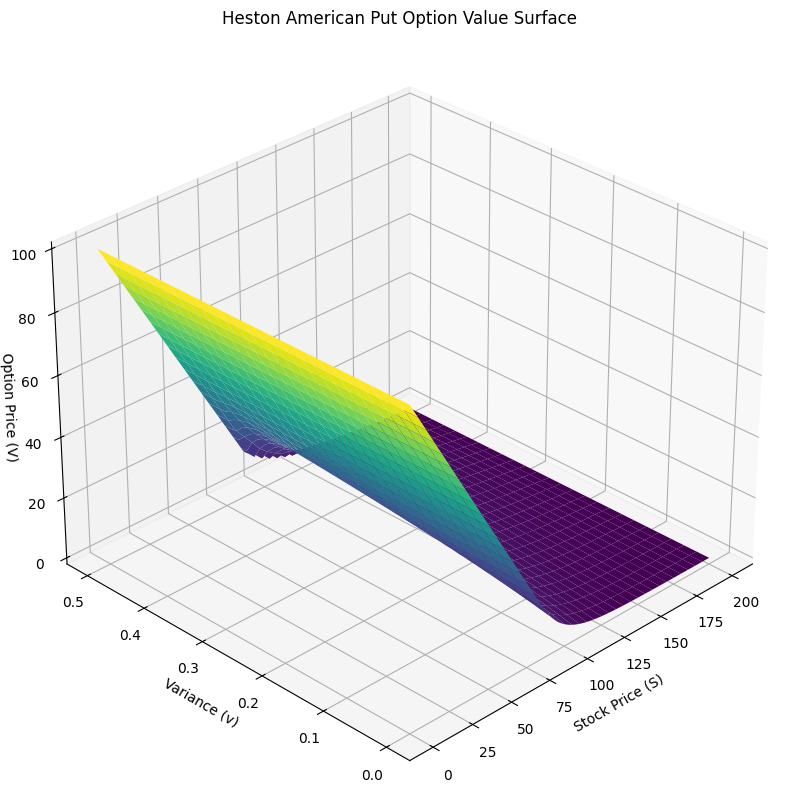

In [6]:
# --- 5. Price the option and visualize the results ---

# v0, theta, kappa, sigma, rho = [0.03, 0.03, 1.5, 0.6, -0.67]

if __name__ == '__main__':
    # Pack parameters into tuples (same convention as the HV function)
    model_params = (v0, theta, kappa, sigma, rho)
    option_params = (K, T, r, q, S0)
    grid_params = (N_S, N_v, N_t, S_max, v_max)

    S_grid = np.linspace(0, S_max, N_S + 1)
    v_grid = np.linspace(0, v_max, N_v + 1)

    price, V_grid = price_american_put_heston_spsolve(model_params, option_params, grid_params)

    print("--- Heston American Put Price (Douglas scheme with spsolve) ---")
    print(f"v0={v0}, theta={theta}, kappa={kappa}, sigma={sigma}, rho={rho}, r={r}, q={q}, T={T}\n")
    print(f"Grid Size: {N_S} (Stock Price) x {N_v} (Variance) x {N_t} (Time)")
    print(f"Price for an at-the-money (S0={S0}, K={K}) American Put Option: {price:.4f}")

    # Plotting
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    S_mat, v_mat = np.meshgrid(S_grid, v_grid, indexing='ij')

    ax.plot_surface(S_mat, v_mat, V_grid, cmap='viridis')
    ax.set_title("Heston American Put Option Value Surface")
    ax.set_xlabel("Stock Price (S)")
    ax.set_ylabel("Variance (v)")
    ax.set_zlabel("Option Price (V)", labelpad=0)
    ax.view_init(30, -135) # Adjust viewing angle
    plt.show()